In [3]:
import os
import time
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')

from sklearn.metrics import confusion_matrix, f1_score, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, random_split

In [4]:
CONFIG = {
    "batch_size": 64,
    "epochs": 20,
    "lr": 1e-3,
    "img_size_small": 64,   # for lightweight CNN
    "img_size_large": 224,  # for ResNet / EfficientNet
    "num_classes": 43,
    "validation_split": 0.2,
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu"
}

print(f"Using Device: {CONFIG['device']}")

Using Device: cuda


In [5]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])

In [7]:
SAVE_DIR = "/kaggle/working/GTSRB_FYP"
os.makedirs(SAVE_DIR, exist_ok=True)

In [9]:
# ── Training Transforms ───────────────────────────────────────
# Includes augmentation to make model robust
train_transform_small = transforms.Compose([
    transforms.Resize((CONFIG["img_size_small"], CONFIG["img_size_small"])),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.3337, 0.3064, 0.3171],   # GTSRB mean
                         [0.2672, 0.2564, 0.2629])    # GTSRB std
])

# ── Test/Val Transforms ───────────────────────────────────────
# No augmentation — just resize, convert, normalize
test_transform_small = transforms.Compose([
    transforms.Resize((CONFIG["img_size_small"], CONFIG["img_size_small"])),
    transforms.ToTensor(),
    transforms.Normalize([0.3337, 0.3064, 0.3171],
                         [0.2672, 0.2564, 0.2629])
])

In [10]:
full_train_dataset = datasets.GTSRB(
    root = './data',
    split = 'train',
    download = True,
    transform = train_transform_small
)

test_dataset = datasets.GTSRB(
    root = './data',
    split = 'test',
    download = True,
    transform = test_transform_small
)

print(f"Total training samples : {len(full_train_dataset)}")
print(f"Total test samples     : {len(test_dataset)}")

100%|██████████| 187M/187M [00:16<00:00, 11.6MB/s] 
100%|██████████| 89.0M/89.0M [00:08<00:00, 11.0MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 149kB/s]

Total training samples : 26640
Total test samples     : 12630


In [11]:
val_size = int(len(full_train_dataset) * CONFIG["validation_split"])
train_size = len(full_train_dataset) - val_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator = torch.Generator().manual_seed(CONFIG["seed"])
)

print(f"Train samples      : {train_size}")
print(f"Validation samples : {val_size}")
print(f"Test samples       : {len(test_dataset)}")

Train samples      : 21312
Validation samples : 5328
Test samples       : 12630


In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size = CONFIG["batch_size"],
    shuffle = True,
    num_workers=2,
    pin_memory= True
)

val_loader = DataLoader(
    val_dataset,
    batch_size = CONFIG["batch_size"],
    shuffle = False,
    num_workers=2,
    pin_memory= True
)

test_loader = DataLoader(
    test_dataset,
    batch_size = CONFIG["batch_size"],
    shuffle = False,
    num_workers=2,
    pin_memory= True
)

In [13]:
images, labels = next(iter(train_loader))

print(f"Batch image shape : {images.shape}")   # [64, 3, 64, 64]
print(f"Batch label shape : {labels.shape}")   # [64]
print(f"Pixel value range : {images.min():.2f} to {images.max():.2f}")
print(f"Label range       : {labels.min()} to {labels.max()}")

Batch image shape : torch.Size([64, 3, 64, 64])
Batch label shape : torch.Size([64])
Pixel value range : -1.25 to 2.71
Label range       : 2 to 42


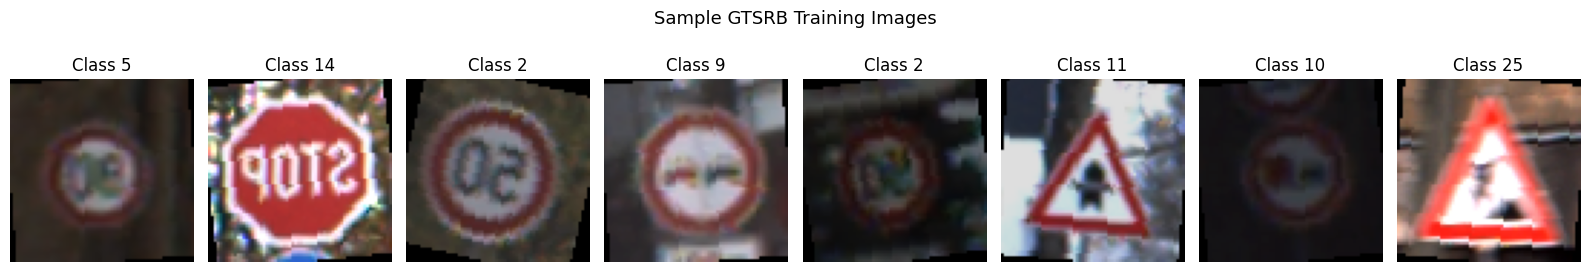

In [14]:
CLASS_NAMES = [str(i) for i in range(43)]  # GTSRB doesn't ship with text names

def show_batch(images, labels, n=8):
    fig, axes = plt.subplots(1, n, figsize=(16, 3))
    for i in range(n):
        img = images[i].permute(1, 2, 0).numpy()
        # Unnormalize for display
        mean = np.array([0.3337, 0.3064, 0.3171])
        std  = np.array([0.2672, 0.2564, 0.2629])
        img  = std * img + mean
        img  = np.clip(img, 0, 1)
        axes[i].imshow(img)
        axes[i].set_title(f"Class {labels[i].item()}")
        axes[i].axis("off")
    plt.suptitle("Sample GTSRB Training Images", fontsize=13)
    plt.tight_layout()
    plt.show()

show_batch(images, labels)

In [15]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

In [16]:
class LightweightCNN(nn.Module):
    def __init__(self, num_classes=43):
        super().__init__()

        # ── Feature Extractor ─────────────────────────────────
        self.features = nn.Sequential(
            ConvBlock(3, 32),           # [B, 32, 64, 64]
            ConvBlock(32, 32),          # [B, 32, 64, 64]
            nn.MaxPool2d(2, 2),         # [B, 32, 32, 32]
            nn.Dropout2d(0.25),

            ConvBlock(32, 64),          # [B, 64, 32, 32]
            ConvBlock(64, 64),          # [B, 64, 32, 32]
            nn.MaxPool2d(2, 2),         # [B, 64, 16, 16]
            nn.Dropout2d(0.25),

            ConvBlock(64, 128),         # [B, 128, 16, 16]
            ConvBlock(128, 128),        # [B, 128, 16, 16]
            nn.MaxPool2d(2, 2),         # [B, 128, 8, 8]
            nn.Dropout2d(0.25),
        )

        # ── Classifier Head ───────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Flatten(),               # [B, 128*8*8] = [B, 8192]
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes) # [B, 43]
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [17]:
model_cnn = LightweightCNN(num_classes=CONFIG['num_classes']).to(CONFIG['device'])

dummy = torch.randn(4, 3, 64, 64).to(CONFIG["device"])
output = model_cnn(dummy)
print(f"Output shape: {output.shape}")  # Expected: torch.Size([4, 43])

Output shape: torch.Size([4, 43])


In [18]:
total_params = sum(p.numel() for p in model_cnn.parameters())
print(f"Total parameters: {total_params / 1e6:.2f}M")

Total parameters: 2.40M


In [19]:
criterion = nn.CrossEntropyLoss()

optim_CNN = optim.Adam(model_cnn.parameters(), lr=CONFIG["lr"])

scheduler_CNN = optim.lr_scheduler.StepLR(optim_CNN, step_size=7, gamma=0.1)

In [20]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()   # activates dropout, batchnorm in train mode

    running_loss    = 0.0
    correct         = 0
    total           = 0

    for images, labels in loader:
        images  = images.to(device)
        labels  = labels.to(device)

        # ── Forward Pass ──────────────────────────────────────
        outputs = model(images)             # [B, 43] raw scores
        loss    = criterion(outputs, labels)

        # ── Backward Pass ─────────────────────────────────────
        optimizer.zero_grad()   # clear old gradients
        loss.backward()         # compute new gradients
        optimizer.step()        # update weights

        # ── Track Metrics ─────────────────────────────────────
        running_loss += loss.item() * images.size(0)
        _, predicted  = torch.max(outputs, 1)
        total        += labels.size(0)
        correct      += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc

In [24]:
def validate(model, loader, criterion, device):
    model.eval()    # deactivates dropout, batchnorm in eval mode

    running_loss    = 0.0
    correct         = 0
    total           = 0

    with torch.no_grad():   # no gradients needed during validation
        for images, labels in loader:
            images  = images.to(device)
            labels  = labels.to(device)

            outputs      = model(images)
            loss         = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted  = torch.max(outputs, 1)
            total        += labels.size(0)
            correct      += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc

In [25]:
def train_model(model, train_loader, val_loader,
                criterion, optimizer, scheduler,
                epochs, device, model_name="model"):

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss"  : [], "val_acc"  : []
    }

    best_val_acc  = 0.0
    best_model_path = os.path.join(SAVE_DIR, f"{model_name}_best.pth")

    for epoch in range(epochs):
        # ── Train ─────────────────────────────────────────────
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        # ── Validate ──────────────────────────────────────────
        val_loss, val_acc = validate(
            model, val_loader, criterion, device
        )

        # ── Scheduler Step ────────────────────────────────────
        scheduler.step()

        # ── Save Best Model ───────────────────────────────────
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)

        # ── Log ───────────────────────────────────────────────
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch [{epoch+1:02d}/{epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    print(f"\nBest Val Acc: {best_val_acc:.4f} — saved to {best_model_path}")
    return history

In [26]:
def plot_history(history, model_name="Model"):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    ax1.plot(epochs, history["train_loss"], label="Train Loss")
    ax1.plot(epochs, history["val_loss"],   label="Val Loss")
    ax1.set_title(f"{model_name} — Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()

    # Accuracy
    ax2.plot(epochs, history["train_acc"], label="Train Acc")
    ax2.plot(epochs, history["val_acc"],   label="Val Acc")
    ax2.set_title(f"{model_name} — Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"{model_name}_curves.png"), dpi=150)
    plt.show()

Training Lightweight CNN
Epoch [01/20] Train Loss: 2.6722 | Train Acc: 0.2363 | Val Loss: 1.7787 | Val Acc: 0.4052
Epoch [02/20] Train Loss: 1.9036 | Train Acc: 0.3684 | Val Loss: 1.5322 | Val Acc: 0.4636
Epoch [03/20] Train Loss: 1.6784 | Train Acc: 0.4321 | Val Loss: 1.1264 | Val Acc: 0.5882
Epoch [04/20] Train Loss: 1.4113 | Train Acc: 0.5099 | Val Loss: 0.8371 | Val Acc: 0.7081
Epoch [05/20] Train Loss: 1.2097 | Train Acc: 0.5725 | Val Loss: 0.6578 | Val Acc: 0.7434
Epoch [06/20] Train Loss: 1.0790 | Train Acc: 0.6154 | Val Loss: 0.5161 | Val Acc: 0.8273
Epoch [07/20] Train Loss: 0.9595 | Train Acc: 0.6565 | Val Loss: 0.3923 | Val Acc: 0.8529
Epoch [08/20] Train Loss: 0.8166 | Train Acc: 0.7083 | Val Loss: 0.3425 | Val Acc: 0.9007
Epoch [09/20] Train Loss: 0.7594 | Train Acc: 0.7295 | Val Loss: 0.3049 | Val Acc: 0.9108
Epoch [10/20] Train Loss: 0.7383 | Train Acc: 0.7349 | Val Loss: 0.2929 | Val Acc: 0.9131
Epoch [11/20] Train Loss: 0.7261 | Train Acc: 0.7403 | Val Loss: 0.2741 | V

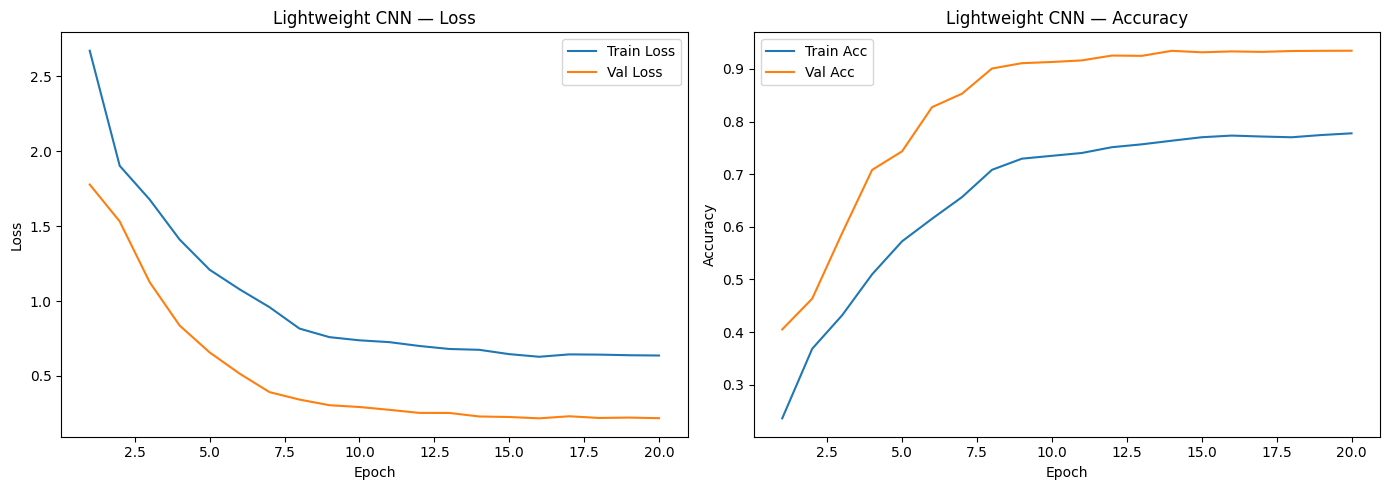

In [27]:
print("=" * 60)
print("Training Lightweight CNN")
print("=" * 60)

history_cnn = train_model(
    model     = model_cnn,
    train_loader = train_loader,
    val_loader   = val_loader,
    criterion    = criterion,
    optimizer    = optim_CNN,
    scheduler    = scheduler_CNN,
    epochs       = CONFIG["epochs"],
    device       = CONFIG["device"],
    model_name   = "lightweight_cnn"
)

plot_history(history_cnn, model_name="Lightweight CNN")

In [29]:
train_transform_large = transforms.Compose([
    transforms.Resize((CONFIG["img_size_large"], CONFIG["img_size_large"])),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],   # ImageNet mean
                         [0.229, 0.224, 0.225])    # ImageNet std
])

test_transform_large = transforms.Compose([
    transforms.Resize((CONFIG["img_size_large"], CONFIG["img_size_large"])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [30]:
full_train_large = datasets.GTSRB(
    root="./data",
    split="train",
    download=False,               # already downloaded
    transform=train_transform_large
)

test_dataset_large = datasets.GTSRB(
    root="./data",
    split="test",
    download=False,
    transform=test_transform_large
)

# Same 80/20 split
val_size_l   = int(len(full_train_large) * CONFIG["validation_split"])
train_size_l = len(full_train_large) - val_size_l

train_dataset_large, val_dataset_large = random_split(
    full_train_large,
    [train_size_l, val_size_l],
    generator=torch.Generator().manual_seed(CONFIG["seed"])
)

train_loader_large = DataLoader(
    train_dataset_large,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_large = DataLoader(
    val_dataset_large,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader_large = DataLoader(
    test_dataset_large,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train: {train_size_l} | Val: {val_size_l} | Test: {len(test_dataset_large)}")

Train: 21312 | Val: 5328 | Test: 12630


In [31]:
model_resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

print(model_resnet)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 235MB/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [32]:
model_resnet.fc = nn.Linear(512, CONFIG['num_classes'])
model_resnet = model_resnet.to(CONFIG['device'])

print(f"New Output Layer: {model_resnet.fc}")

New Output Layer: Linear(in_features=512, out_features=43, bias=True)


In [34]:
for params in model_resnet.parameters():
  params.requires_grad = False

for params in model_resnet.fc.parameters():
  params.requires_grad = True

In [35]:
criterion_resnet   = nn.CrossEntropyLoss()

optimizer_resnet_p1 = optim.Adam(
    filter(lambda p: p.requires_grad, model_resnet.parameters()),
    lr=1e-3
)

scheduler_resnet_p1 = optim.lr_scheduler.StepLR(
    optimizer_resnet_p1,
    step_size=3,
    gamma=0.1
)

print("=" * 60)
print("ResNet-18 — Phase 1: Head Only (5 epochs)")
print("=" * 60)

history_resnet_p1 = train_model(
    model        = model_resnet,
    train_loader = train_loader_large,
    val_loader   = val_loader_large,
    criterion    = criterion_resnet,
    optimizer    = optimizer_resnet_p1,
    scheduler    = scheduler_resnet_p1,
    epochs       = 5,
    device       = CONFIG["device"],
    model_name   = "resnet18_phase1"
)

ResNet-18 — Phase 1: Head Only (5 epochs)
Epoch [01/5] Train Loss: 1.9332 | Train Acc: 0.4974 | Val Loss: 1.3152 | Val Acc: 0.6532
Epoch [02/5] Train Loss: 1.1648 | Train Acc: 0.6762 | Val Loss: 0.9977 | Val Acc: 0.7170
Epoch [03/5] Train Loss: 0.9540 | Train Acc: 0.7252 | Val Loss: 0.8722 | Val Acc: 0.7462
Epoch [04/5] Train Loss: 0.8327 | Train Acc: 0.7658 | Val Loss: 0.8507 | Val Acc: 0.7547
Epoch [05/5] Train Loss: 0.8291 | Train Acc: 0.7657 | Val Loss: 0.8305 | Val Acc: 0.7650

Best Val Acc: 0.7650 — saved to /kaggle/working/GTSRB_FYP/resnet18_phase1_best.pth


In [36]:
# Unfreeze all layers
for param in model_resnet.parameters():
    param.requires_grad = True

optimizer_resnet_p2 = optim.Adam(
    model_resnet.parameters(),
    lr=1e-4          # 10x lower than Phase 1 — gentle fine-tuning
)

scheduler_resnet_p2 = optim.lr_scheduler.StepLR(
    optimizer_resnet_p2,
    step_size=5,
    gamma=0.1
)

print("=" * 60)
print("ResNet-18 — Phase 2: Full Fine-Tuning (15 epochs)")
print("=" * 60)

history_resnet_p2 = train_model(
    model        = model_resnet,
    train_loader = train_loader_large,
    val_loader   = val_loader_large,
    criterion    = criterion_resnet,
    optimizer    = optimizer_resnet_p2,
    scheduler    = scheduler_resnet_p2,
    epochs       = 15,
    device       = CONFIG["device"],
    model_name   = "resnet18_best"
)

ResNet-18 — Phase 2: Full Fine-Tuning (15 epochs)
Epoch [01/15] Train Loss: 0.1657 | Train Acc: 0.9489 | Val Loss: 0.0514 | Val Acc: 0.9863
Epoch [02/15] Train Loss: 0.0250 | Train Acc: 0.9930 | Val Loss: 0.0219 | Val Acc: 0.9936
Epoch [03/15] Train Loss: 0.0157 | Train Acc: 0.9959 | Val Loss: 0.0202 | Val Acc: 0.9955
Epoch [04/15] Train Loss: 0.0111 | Train Acc: 0.9971 | Val Loss: 0.0123 | Val Acc: 0.9968
Epoch [05/15] Train Loss: 0.0111 | Train Acc: 0.9968 | Val Loss: 0.0064 | Val Acc: 0.9985
Epoch [06/15] Train Loss: 0.0039 | Train Acc: 0.9991 | Val Loss: 0.0047 | Val Acc: 0.9989
Epoch [07/15] Train Loss: 0.0019 | Train Acc: 0.9997 | Val Loss: 0.0025 | Val Acc: 0.9996
Epoch [08/15] Train Loss: 0.0017 | Train Acc: 0.9997 | Val Loss: 0.0020 | Val Acc: 1.0000
Epoch [09/15] Train Loss: 0.0013 | Train Acc: 0.9998 | Val Loss: 0.0019 | Val Acc: 0.9996
Epoch [10/15] Train Loss: 0.0009 | Train Acc: 1.0000 | Val Loss: 0.0022 | Val Acc: 0.9998
Epoch [11/15] Train Loss: 0.0009 | Train Acc: 1.00

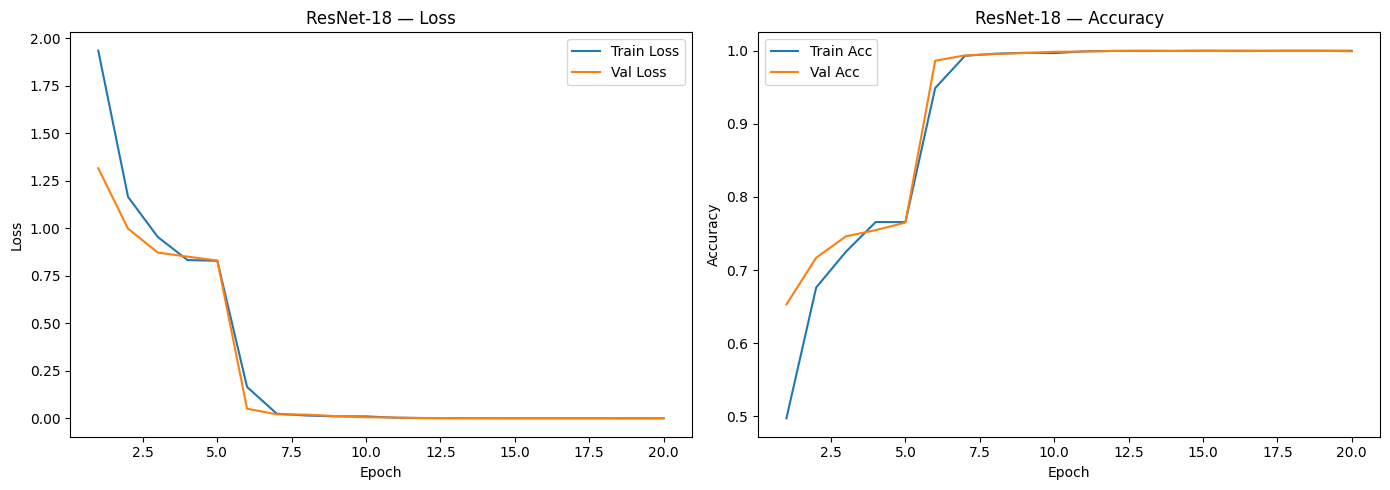

In [37]:
# Merge histories for full picture
history_resnet_full = {
    "train_loss": history_resnet_p1["train_loss"] + history_resnet_p2["train_loss"],
    "train_acc" : history_resnet_p1["train_acc"]  + history_resnet_p2["train_acc"],
    "val_loss"  : history_resnet_p1["val_loss"]   + history_resnet_p2["val_loss"],
    "val_acc"   : history_resnet_p1["val_acc"]    + history_resnet_p2["val_acc"],
}

plot_history(history_resnet_full, model_name="ResNet-18")

In [38]:
model_effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

print(model_effnet.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 173MB/s]

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


In [39]:
model_effnet.classifier[1] = nn.Linear(1280, CONFIG['num_classes'])

model_effnet = model_effnet.to(CONFIG['device'])

print(f"New Output Layer: {model_effnet.classifier[1]}")

New Output Layer: Linear(in_features=1280, out_features=43, bias=True)


In [40]:
total_params = sum(p.numel() for p in model_effnet.parameters())
print(f"Total parameters: {total_params / 1e6:.2f}M")

Total parameters: 4.06M


In [41]:
# Freeze entire backbone
for param in model_effnet.parameters():
    param.requires_grad = False

# Unfreeze only classifier head
for param in model_effnet.classifier.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model_effnet.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_effnet.parameters())
print(f"Trainable: {trainable:,} / {total:,}")

criterion_effnet    = nn.CrossEntropyLoss()

optimizer_effnet_p1 = optim.Adam(
    filter(lambda p: p.requires_grad, model_effnet.parameters()),
    lr=1e-3
)

scheduler_effnet_p1 = optim.lr_scheduler.StepLR(
    optimizer_effnet_p1,
    step_size=3,
    gamma=0.1
)

print("=" * 60)
print("EfficientNet-B0 — Phase 1: Head Only (5 epochs)")
print("=" * 60)

history_effnet_p1 = train_model(
    model        = model_effnet,
    train_loader = train_loader_large,
    val_loader   = val_loader_large,
    criterion    = criterion_effnet,
    optimizer    = optimizer_effnet_p1,
    scheduler    = scheduler_effnet_p1,
    epochs       = 5,
    device       = CONFIG["device"],
    model_name   = "effnet_phase1"
)

Trainable: 55,083 / 4,062,631
EfficientNet-B0 — Phase 1: Head Only (5 epochs)
Epoch [01/5] Train Loss: 1.8633 | Train Acc: 0.5290 | Val Loss: 1.1857 | Val Acc: 0.6954
Epoch [02/5] Train Loss: 1.1211 | Train Acc: 0.6920 | Val Loss: 0.8665 | Val Acc: 0.7654
Epoch [03/5] Train Loss: 0.9306 | Train Acc: 0.7355 | Val Loss: 0.7605 | Val Acc: 0.7892
Epoch [04/5] Train Loss: 0.8490 | Train Acc: 0.7588 | Val Loss: 0.7328 | Val Acc: 0.7952
Epoch [05/5] Train Loss: 0.8358 | Train Acc: 0.7621 | Val Loss: 0.7005 | Val Acc: 0.8084

Best Val Acc: 0.8084 — saved to /kaggle/working/GTSRB_FYP/effnet_phase1_best.pth


In [42]:
# Unfreeze everything
for param in model_effnet.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model_effnet.parameters() if p.requires_grad)
print(f"All parameters trainable: {trainable:,}")

optimizer_effnet_p2 = optim.Adam(
    model_effnet.parameters(),
    lr=1e-4          # lower LR for gentle fine-tuning
)

scheduler_effnet_p2 = optim.lr_scheduler.StepLR(
    optimizer_effnet_p2,
    step_size=5,
    gamma=0.1
)

print("=" * 60)
print("EfficientNet-B0 — Phase 2: Full Fine-Tuning (15 epochs)")
print("=" * 60)

history_effnet_p2 = train_model(
    model        = model_effnet,
    train_loader = train_loader_large,
    val_loader   = val_loader_large,
    criterion    = criterion_effnet,
    optimizer    = optimizer_effnet_p2,
    scheduler    = scheduler_effnet_p2,
    epochs       = 15,
    device       = CONFIG["device"],
    model_name   = "effnet_best"
)

All parameters trainable: 4,062,631
EfficientNet-B0 — Phase 2: Full Fine-Tuning (15 epochs)
Epoch [01/15] Train Loss: 0.2540 | Train Acc: 0.9256 | Val Loss: 0.0600 | Val Acc: 0.9850
Epoch [02/15] Train Loss: 0.0635 | Train Acc: 0.9825 | Val Loss: 0.0238 | Val Acc: 0.9936
Epoch [03/15] Train Loss: 0.0289 | Train Acc: 0.9924 | Val Loss: 0.0149 | Val Acc: 0.9966
Epoch [04/15] Train Loss: 0.0173 | Train Acc: 0.9957 | Val Loss: 0.0071 | Val Acc: 0.9972
Epoch [05/15] Train Loss: 0.0103 | Train Acc: 0.9978 | Val Loss: 0.0048 | Val Acc: 0.9985
Epoch [06/15] Train Loss: 0.0085 | Train Acc: 0.9980 | Val Loss: 0.0047 | Val Acc: 0.9981
Epoch [07/15] Train Loss: 0.0066 | Train Acc: 0.9982 | Val Loss: 0.0031 | Val Acc: 0.9994
Epoch [08/15] Train Loss: 0.0062 | Train Acc: 0.9986 | Val Loss: 0.0035 | Val Acc: 0.9992
Epoch [09/15] Train Loss: 0.0058 | Train Acc: 0.9987 | Val Loss: 0.0032 | Val Acc: 0.9989
Epoch [10/15] Train Loss: 0.0053 | Train Acc: 0.9987 | Val Loss: 0.0032 | Val Acc: 0.9991
Epoch [1

In [50]:
# Load best weights for each model
model_cnn.load_state_dict(
    torch.load(os.path.join(SAVE_DIR, "lightweight_cnn_best.pth"),
               map_location=CONFIG["device"])
)

model_resnet.load_state_dict(
    torch.load(os.path.join(SAVE_DIR, "resnet18_best_best.pth"),
               map_location=CONFIG["device"])
)

model_effnet.load_state_dict(
    torch.load(os.path.join(SAVE_DIR, "effnet_best_best.pth"),
               map_location=CONFIG["device"])
)

print("All best weights loaded.")

All best weights loaded.


In [51]:
def get_predictions(model, loader, device):
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)

In [52]:
# CNN uses small loader, ResNet & EfficientNet use large loader
labels_cnn, preds_cnn    = get_predictions(model_cnn, test_loader, CONFIG["device"])
labels_resnet, preds_resnet = get_predictions(model_resnet, test_loader_large, CONFIG["device"])
labels_effnet, preds_effnet = get_predictions(model_effnet, test_loader_large, CONFIG["device"])

print("Predictions collected for all three models.")

Predictions collected for all three models.


In [53]:
from sklearn.metrics import accuracy_score, f1_score

def print_metrics(name, labels, preds):
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average='macro')
    print(f"{name}")
    print(f"  Test Accuracy : {acc:.4f}")
    print(f"  Macro F1      : {f1:.4f}")
    print()

print_metrics("Lightweight CNN", labels_cnn, preds_cnn)
print_metrics("ResNet-18", labels_resnet, preds_resnet)
print_metrics("EfficientNet-B0", labels_effnet, preds_effnet)

Lightweight CNN
  Test Accuracy : 0.9008
  Macro F1      : 0.7806

ResNet-18
  Test Accuracy : 0.9599
  Macro F1      : 0.9096

EfficientNet-B0
  Test Accuracy : 0.9508
  Macro F1      : 0.9004



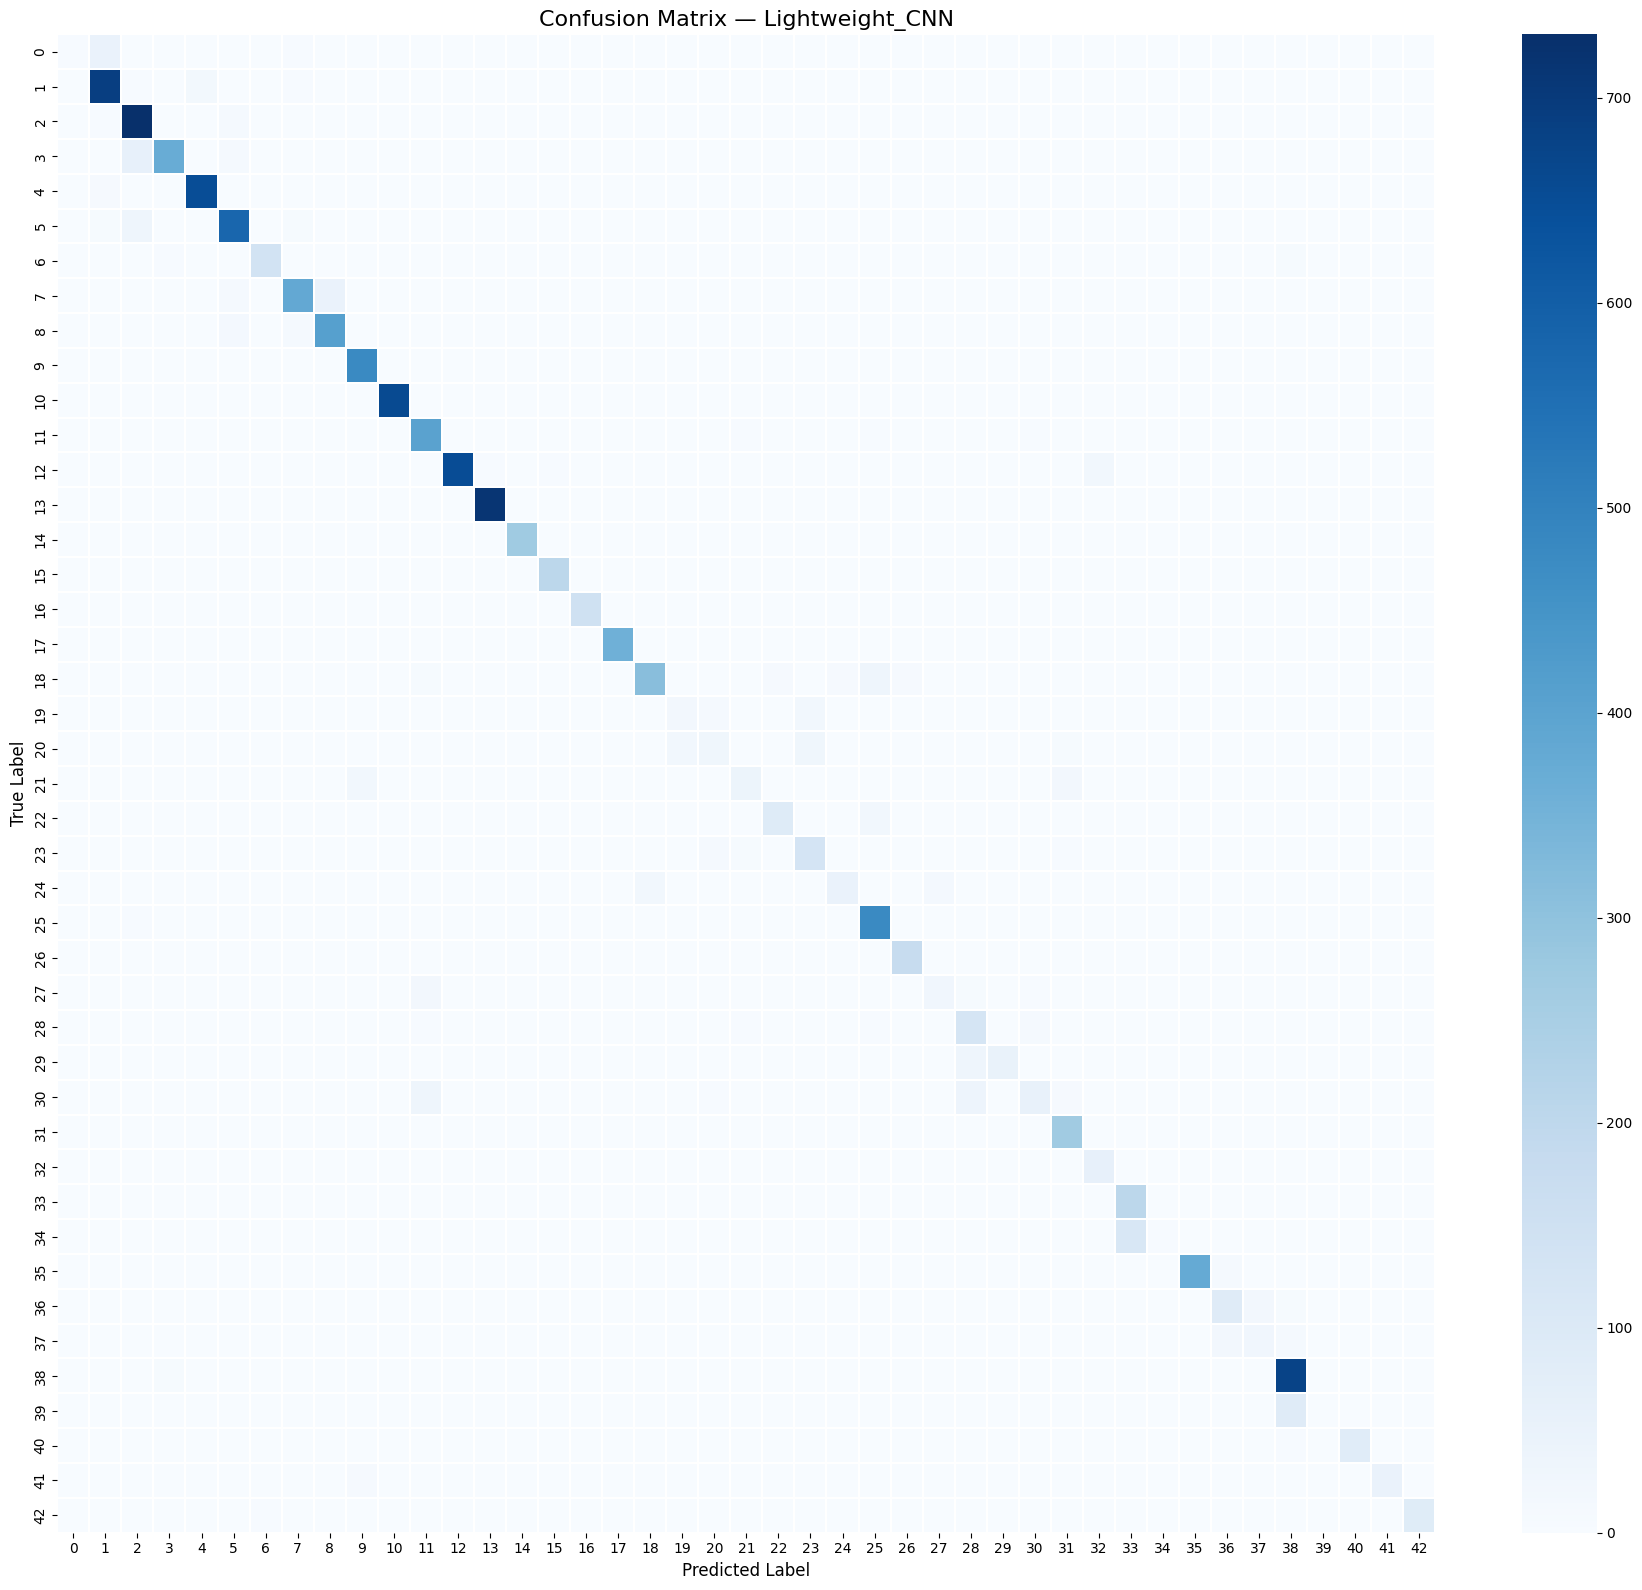

Saved confusion matrix for Lightweight_CNN


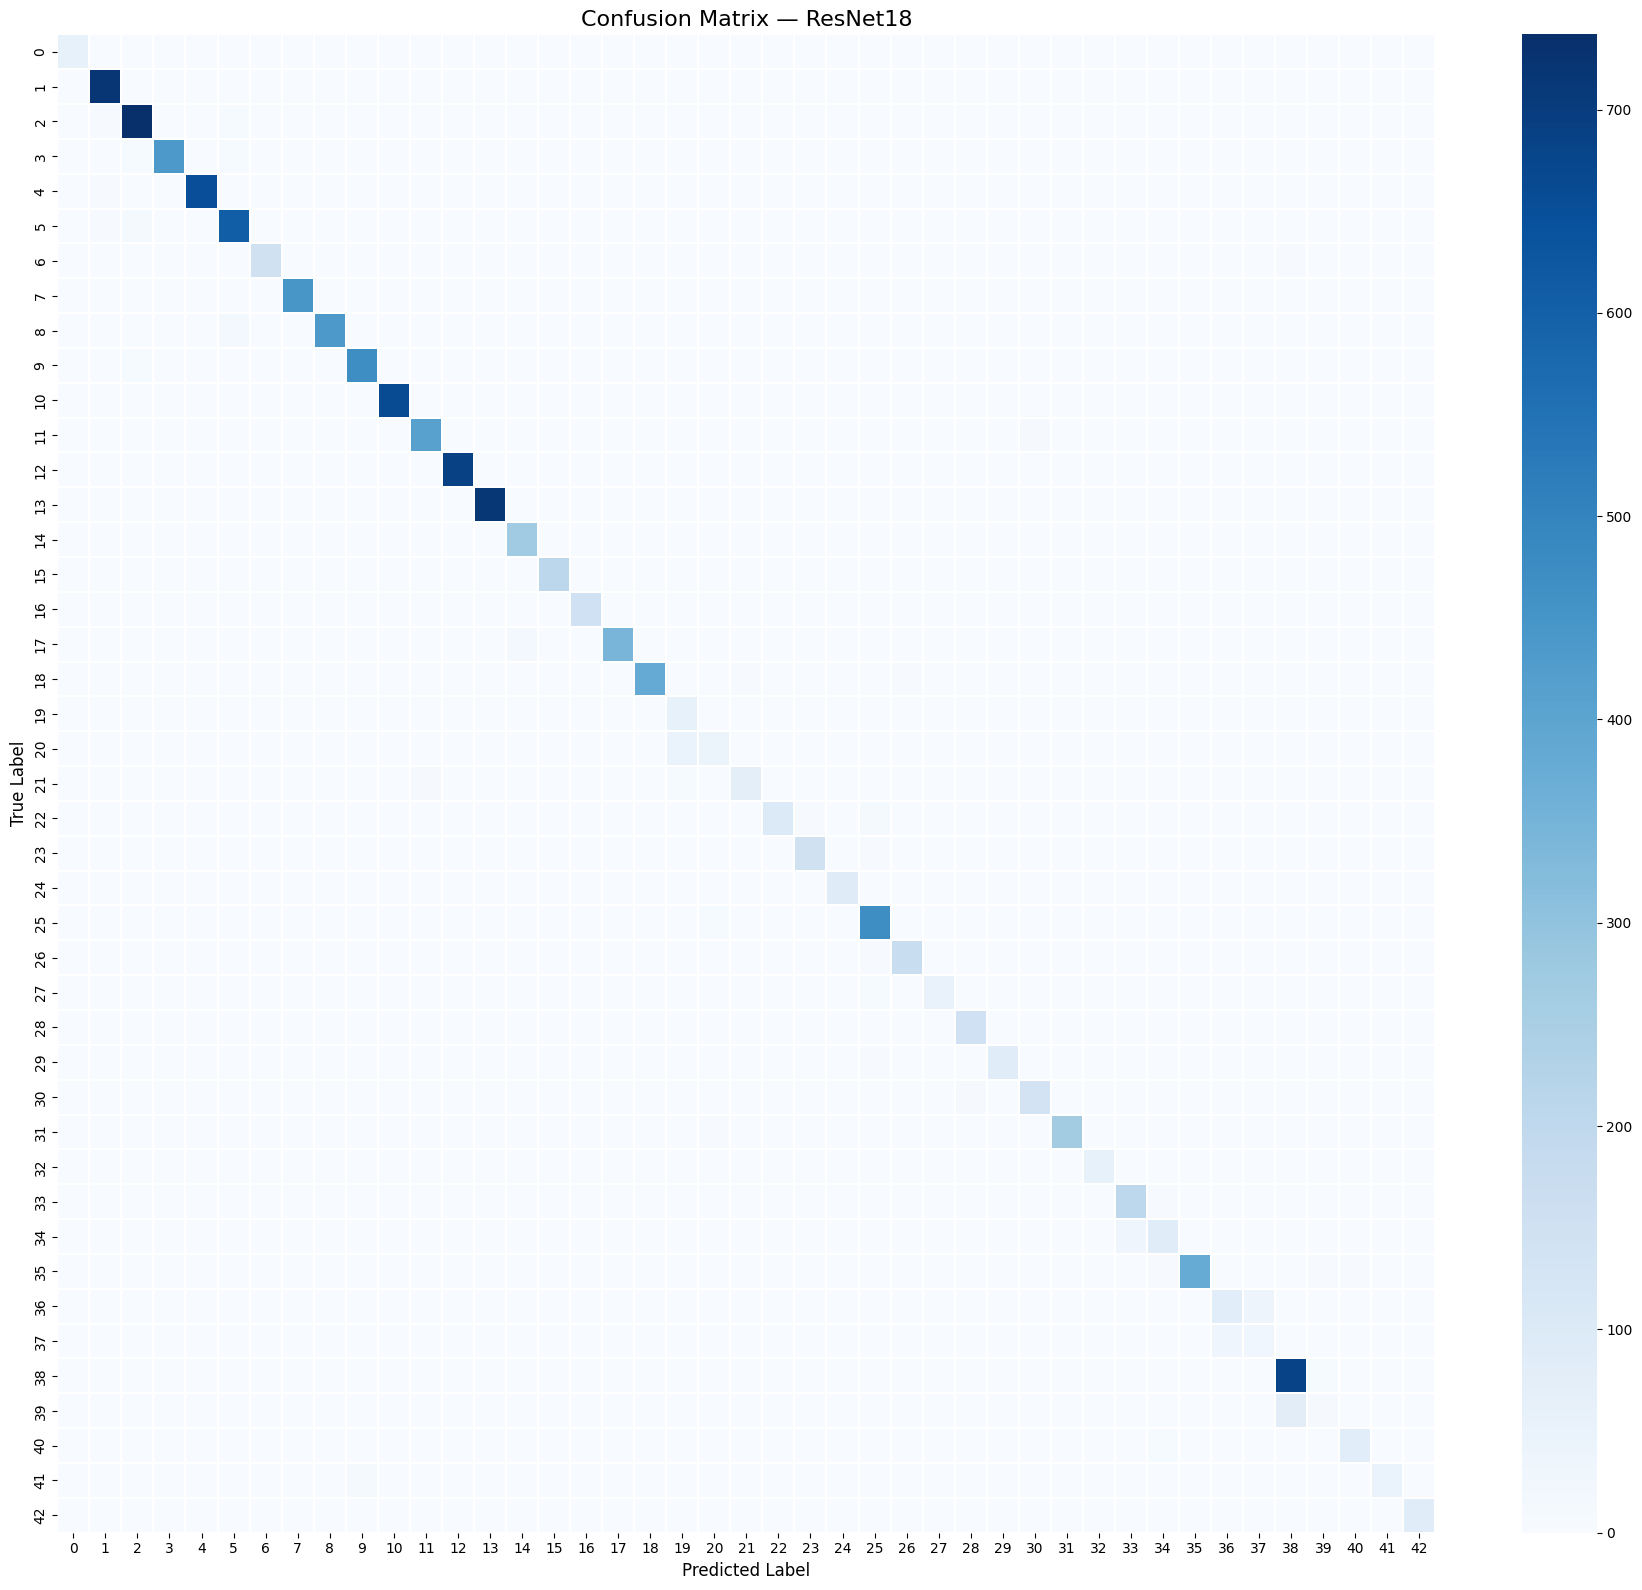

Saved confusion matrix for ResNet18


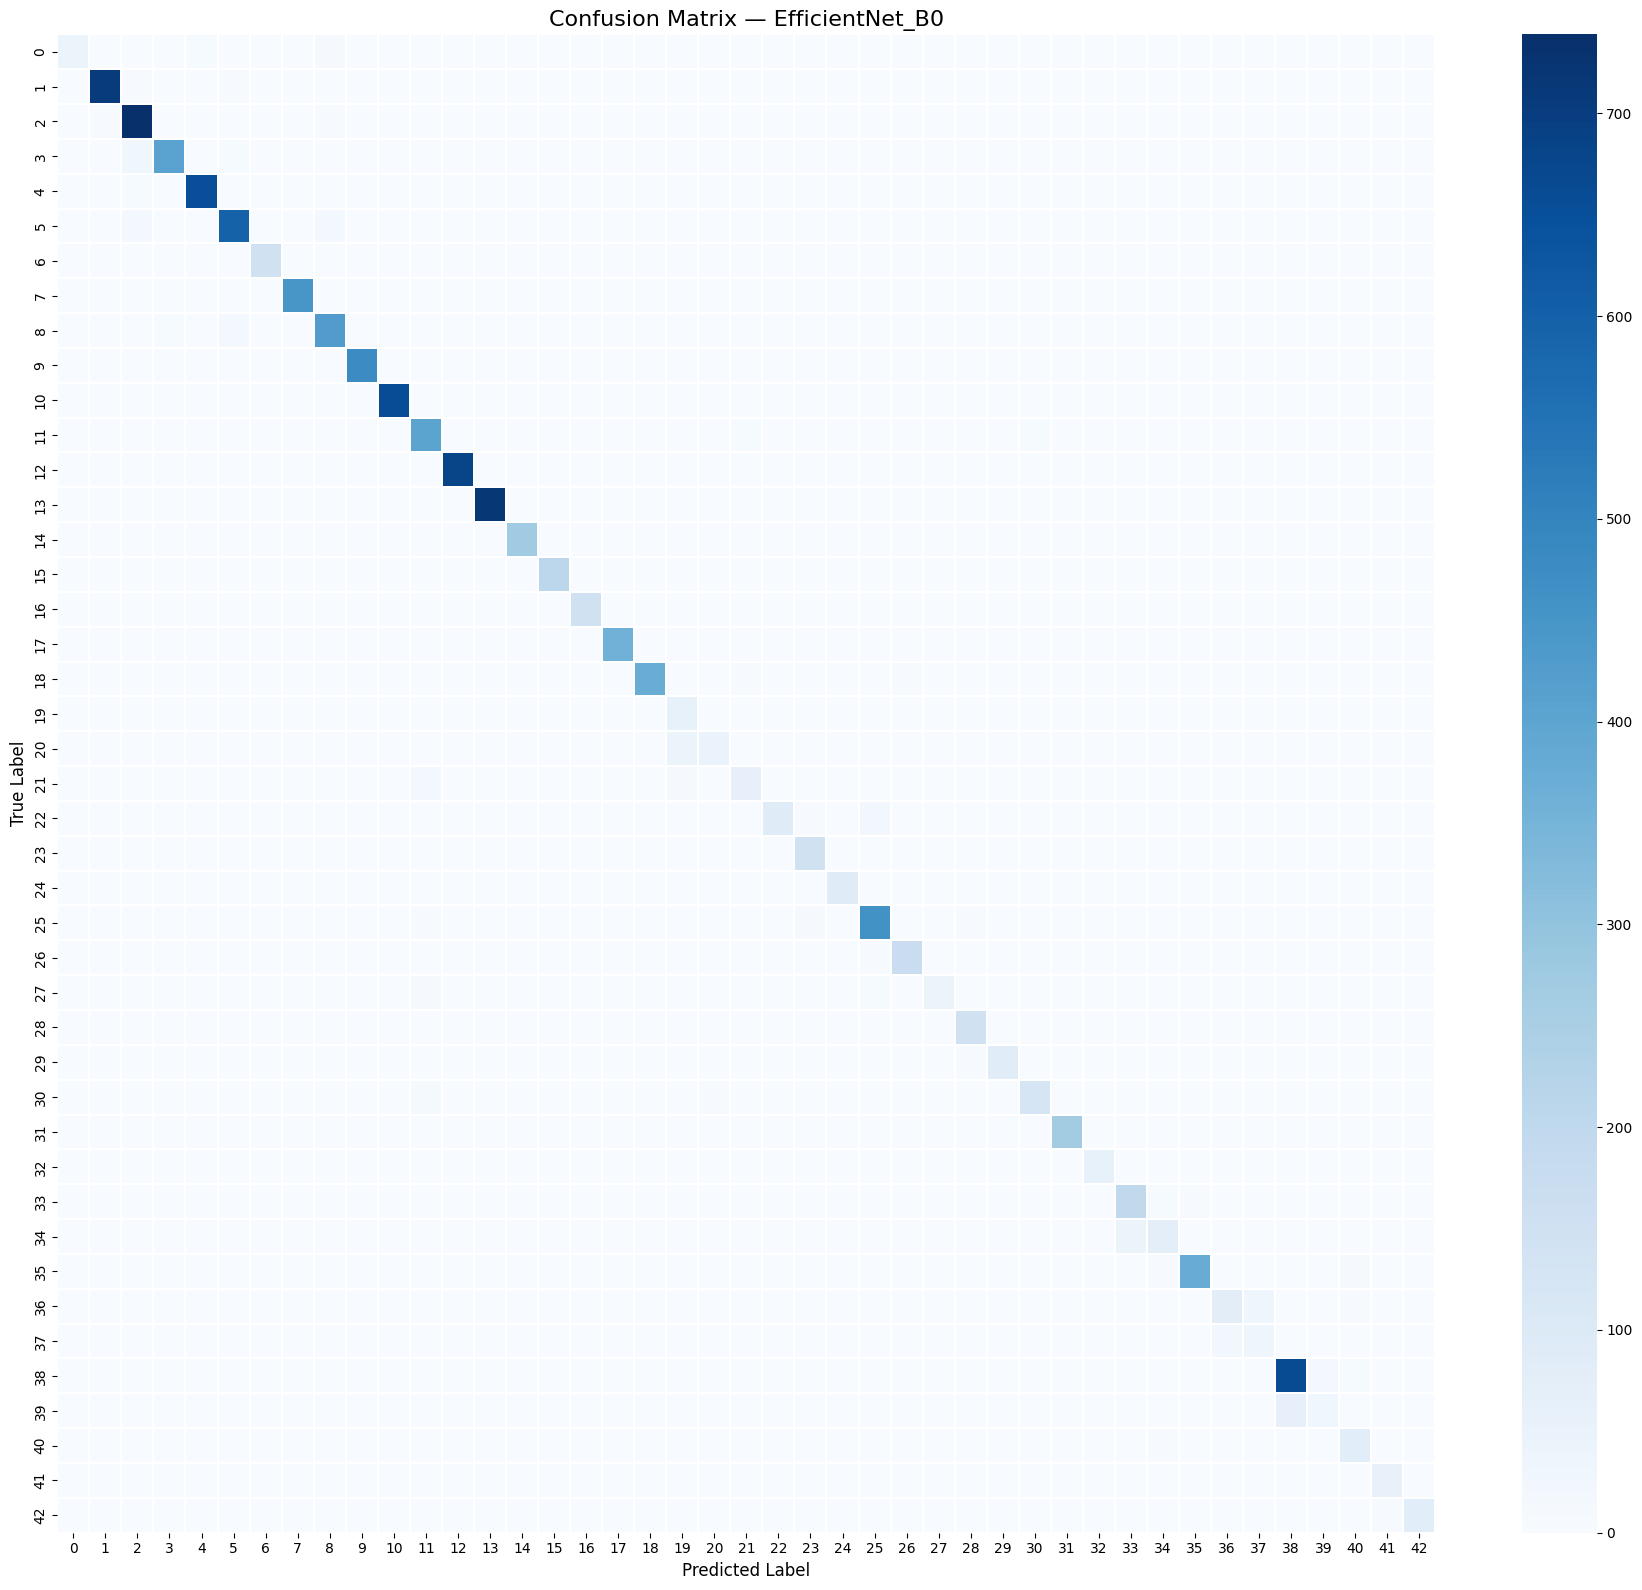

Saved confusion matrix for EfficientNet_B0


In [54]:
def plot_confusion_matrix(name, labels, preds):
    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(18, 16))
    sns.heatmap(
        cm,
        annot=False,
        fmt='d',
        cmap='Blues',
        linewidths=0.3
    )
    plt.title(f"Confusion Matrix — {name}", fontsize=16)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.tight_layout()
    plt.savefig(
        os.path.join(SAVE_DIR, f"confusion_matrix_{name.replace(' ', '_')}.png"),
        dpi=150
    )
    plt.show()
    print(f"Saved confusion matrix for {name}")

plot_confusion_matrix("Lightweight_CNN",  labels_cnn,    preds_cnn)
plot_confusion_matrix("ResNet18",         labels_resnet, preds_resnet)
plot_confusion_matrix("EfficientNet_B0",  labels_effnet, preds_effnet)

In [55]:
def benchmark_speed(name, model, input_size, device, num_runs=200):
    model.eval()
    dummy = torch.randn(1, 3, input_size, input_size).to(device)

    # Warmup — GPU needs a few passes to reach stable speed
    for _ in range(20):
        with torch.no_grad():
            _ = model(dummy)

    # Benchmark
    start = time.time()
    with torch.no_grad():
        for _ in range(num_runs):
            _ = model(dummy)
    end = time.time()

    avg_ms  = (end - start) / num_runs * 1000
    fps     = 1000 / avg_ms

    print(f"{name}")
    print(f"  Avg Latency : {avg_ms:.2f} ms/image")
    print(f"  Throughput  : {fps:.1f} FPS")
    print()

    return avg_ms, fps

ms_cnn,    fps_cnn    = benchmark_speed("Lightweight CNN",  model_cnn,    64,  CONFIG["device"])
ms_resnet, fps_resnet = benchmark_speed("ResNet-18",        model_resnet, 224, CONFIG["device"])
ms_effnet, fps_effnet = benchmark_speed("EfficientNet-B0",  model_effnet, 224, CONFIG["device"])

Lightweight CNN
  Avg Latency : 0.94 ms/image
  Throughput  : 1064.9 FPS

ResNet-18
  Avg Latency : 2.33 ms/image
  Throughput  : 429.6 FPS

EfficientNet-B0
  Avg Latency : 7.45 ms/image
  Throughput  : 134.3 FPS



In [56]:
def get_model_size(name, path):
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f"{name} — Model Size: {size_mb:.2f} MB")
    return size_mb

size_cnn    = get_model_size("Lightweight CNN",  os.path.join(SAVE_DIR, "lightweight_cnn_best.pth"))
size_resnet = get_model_size("ResNet-18",        os.path.join(SAVE_DIR, "resnet18_best_best.pth"))
size_effnet = get_model_size("EfficientNet-B0",  os.path.join(SAVE_DIR, "effnet_best_best.pth"))

Lightweight CNN — Model Size: 9.16 MB
ResNet-18 — Model Size: 42.80 MB
EfficientNet-B0 — Model Size: 15.79 MB


In [57]:
import pandas as pd

results = {
    "Model": [
        "Lightweight CNN",
        "ResNet-18",
        "EfficientNet-B0"
    ],
    "Test Accuracy": [
        round(accuracy_score(labels_cnn,    preds_cnn),    4),
        round(accuracy_score(labels_resnet, preds_resnet), 4),
        round(accuracy_score(labels_effnet, preds_effnet), 4),
    ],
    "Macro F1": [
        round(f1_score(labels_cnn,    preds_cnn,    average='macro'), 4),
        round(f1_score(labels_resnet, preds_resnet, average='macro'), 4),
        round(f1_score(labels_effnet, preds_effnet, average='macro'), 4),
    ],
    "Latency (ms)": [
        round(ms_cnn, 2),
        round(ms_resnet, 2),
        round(ms_effnet, 2)
    ],
    "FPS": [
        round(fps_cnn, 1),
        round(fps_resnet, 1),
        round(fps_effnet, 1)
    ],
    "Model Size (MB)": [
        round(size_cnn, 2),
        round(size_resnet, 2),
        round(size_effnet, 2)
    ]
}

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# Save to Drive
df_results.to_csv(os.path.join(SAVE_DIR, "comparison_results.csv"), index=False)
print("\nSaved comparison table to Drive.")

          Model  Test Accuracy  Macro F1  Latency (ms)    FPS  Model Size (MB)
Lightweight CNN         0.9008    0.7806          0.94 1064.9             9.16
      ResNet-18         0.9599    0.9096          2.33  429.6            42.80
EfficientNet-B0         0.9508    0.9004          7.45  134.3            15.79

Saved comparison table to Drive.


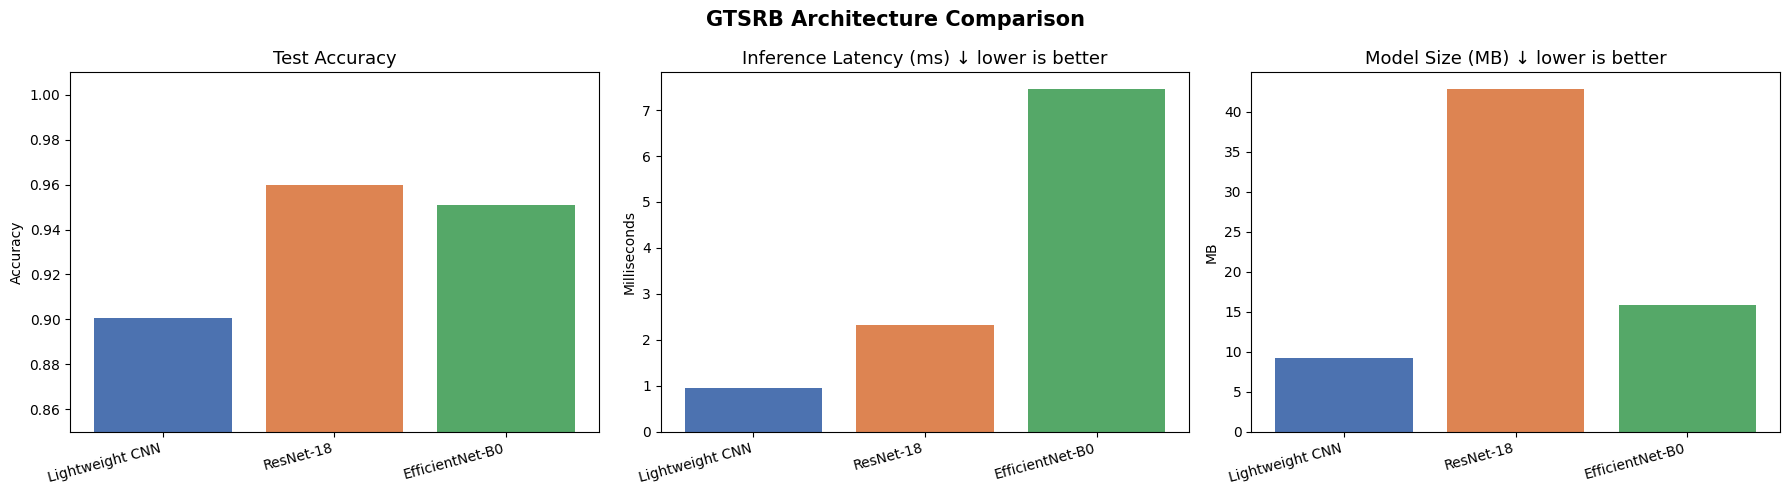

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models     = ["Lightweight CNN", "ResNet-18", "EfficientNet-B0"]
colors     = ["#4C72B0", "#DD8452", "#55A868"]

# Accuracy
axes[0].bar(models, df_results["Test Accuracy"], color=colors)
axes[0].set_title("Test Accuracy", fontsize=13)
axes[0].set_ylim(0.85, 1.01)
axes[0].set_ylabel("Accuracy")

# Latency
axes[1].bar(models, df_results["Latency (ms)"], color=colors)
axes[1].set_title("Inference Latency (ms) ↓ lower is better", fontsize=13)
axes[1].set_ylabel("Milliseconds")

# Model Size
axes[2].bar(models, df_results["Model Size (MB)"], color=colors)
axes[2].set_title("Model Size (MB) ↓ lower is better", fontsize=13)
axes[2].set_ylabel("MB")

for ax in axes:
    ax.set_xticklabels(models, rotation=15, ha='right')

plt.suptitle("GTSRB Architecture Comparison", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "comparison_charts.png"), dpi=150)
plt.show()